# Task 1 — System Ingestion & Model Environment Setup
**PlaceMux AI/ML Developer · Phase 1 Industry Immersion**

Objective: Reproducible ML environment · Correct data split · Smoke-test run with logged metrics

In [1]:
# ── 1. Imports & Seed Fixing ──────────────────────────────────────────────
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import sys, os

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sys.path.insert(0, os.path.join('..', 'src'))
from data_loader import load_data, verify_data, set_seeds
from train import split_data, run_smoke_test, log_metrics

print('✅ All imports successful. Seeds fixed at:', RANDOM_SEED)

✅ All imports successful. Seeds fixed at: 42


In [2]:
# ── 2. Load Dataset ───────────────────────────────────────────────────────
df = load_data('../data/loan_default_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000, 8)


,age,income,loan_amount,credit_score,employment_years,num_accounts,missed_payments,default
0,56,54674,1105,553,16,1,4,1
1,69,55854,10078,725,1,4,4,1
2,46,66271,26003,846,26,4,4,1
3,32,93688,7090,601,8,7,0,1
4,60,58518,39850,648,28,7,3,1


In [3]:
# ── 3. Verify Data Quality ────────────────────────────────────────────────
report = verify_data(df, target_col='default')
print('Null counts:', report['null_counts'])
print('Duplicates:', report['duplicates'])
print('Class balance:', report['class_balance'])
df.info()

Null counts: {'age': 0, 'income': 0, 'loan_amount': 0, 'credit_score': 0, 'employment_years': 0, 'num_accounts': 0, 'missed_payments': 0, 'default': 0}
Duplicates: 0
Class balance: {1: 789, 0: 211}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               1000 non-null   int64
 1   income            1000 non-null   int64
 2   loan_amount       1000 non-null   int64
 3   credit_score      1000 non-null   int64
 4   employment_years  1000 non-null   int64
 5   num_accounts      1000 non-null   int64
 6   missed_payments   1000 non-null   int64
 7   default           1000 non-null   int64
dtypes: int64(8)
memory usage: 62.6 KB


C:\Users\vedan\AppData\Local\Temp\ipykernel_11448\4082769214.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[['credit_score','income','loan_amount']].hist(ax=axes[1], bins=20, color='steelblue')


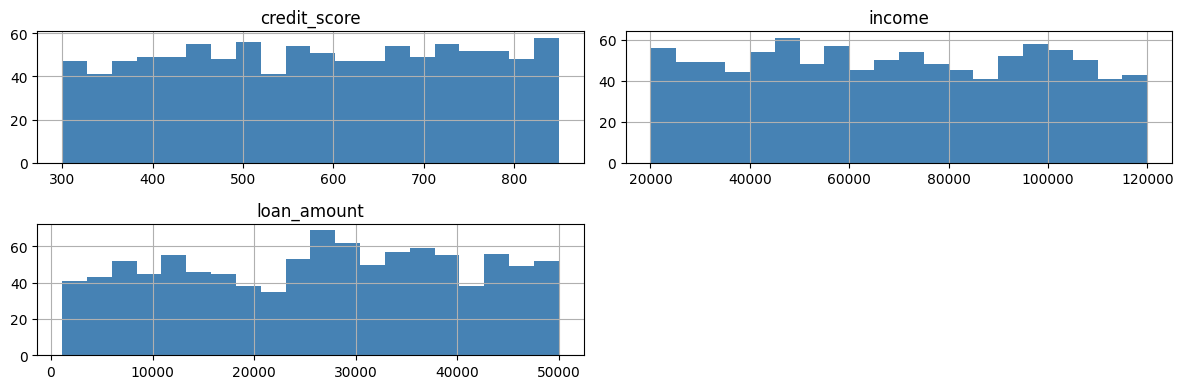

✅ EDA plots saved.


In [4]:
# ── 4. Class Balance Visualisation ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['default'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (default)')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
df[['credit_score','income','loan_amount']].hist(ax=axes[1], bins=20, color='steelblue')
axes[1].set_title('Feature Distributions')
plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=100)
plt.show()
print('✅ EDA plots saved.')

In [5]:
# ── 5. Train / Validation / Test Split (Stratified) ──────────────────────
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df, target_col='default')
print(f'Train : {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Val   : {X_val.shape[0]} rows ({X_val.shape[0]/len(df)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.0f}%)')
print('\nClass balance in splits:')
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'  {name}: {y.value_counts().to_dict()}')

Train: (700, 7), Val: (150, 7), Test: (150, 7)
Train : 700 rows (70%)
Val   : 150 rows (15%)
Test  : 150 rows (15%)

Class balance in splits:
  Train: {1: 552, 0: 148}
  Val: {1: 119, 0: 31}
  Test: {1: 118, 0: 32}


In [6]:
# ── 6. Smoke Test — Dummy Classifier ─────────────────────────────────────
clf, val_acc, val_f1 = run_smoke_test(X_train, X_val, y_train, y_val)
print(classification_report(y_val, clf.predict(X_val), target_names=['No Default','Default']))
print(f'✅ Smoke test PASSED | Val Accuracy: {val_acc} | Val F1: {val_f1}')

              precision    recall  f1-score   support

  No Default       0.00      0.00      0.00        31
     Default       0.79      1.00      0.88       119

    accuracy                           0.79       150
   macro avg       0.40      0.50      0.44       150
weighted avg       0.63      0.79      0.70       150

✅ Smoke test PASSED | Val Accuracy: 0.7933 | Val F1: 0.8848


C:\Users\vedan\PycharmProjects\AI-ML\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vedan\PycharmProjects\AI-ML\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vedan\PycharmProjects\AI-ML\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [7]:
# ── 7. Log Metrics ───────────────────────────────────────────────────────
log_metrics(
    model_name='DummyClassifier',
    accuracy=val_acc,
    f1=val_f1,
    dataset='loan_default_dataset.csv',
    params='strategy=most_frequent',
    log_path='../metrics.csv'
)
pd.read_csv('../metrics.csv')

Logged → ../metrics.csv: DummyClassifier | acc=0.7933 | f1=0.8848


,timestamp,model,accuracy,f1_score,dataset,params
0,2026-08-10 05:57:23,DummyClassifier,0.7933,0.8848,loan_default_dataset.csv,strategy=most_frequent
1,2026-08-10 11:40:47,DummyClassifier,0.7933,0.8848,loan_default_dataset.csv,strategy=most_frequent


## ✅ Task 1 Complete

| Check | Status |
|---|---|
| Seeds fixed | ✅ |
| Dataset loaded & verified | ✅ |
| 70/15/15 stratified split | ✅ |
| Smoke test passed | ✅ |
| Metrics logged | ✅ |

**Next**: Task 2 will build a real baseline model on this foundation.